# Supervised Prediction - HP Tunning with CV

In [122]:
### IMPORTS
# Core data manipulation and numerical computing libraries.
import pandas as pd
import numpy as np

# Plotting utilities used throughout the exploratory and final-fit plots.
import matplotlib.pyplot as plt
from IPython.display import display
plt.style.use('default')

# Linear models used as the base estimators for polynomial and spline regression.
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso

# Model-assessment metric used for every method comparison.
from sklearn.metrics import mean_squared_error

# Resampling utilities for train/test splits, k-fold CV, LOOCV, and CV predictions.
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score

# Pipeline helper lets preprocessing steps and regression models act as one estimator.
from sklearn.pipeline import make_pipeline

# Feature constructors used for nonlinear regression models.
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import SplineTransformer
from sklearn.preprocessing import StandardScaler

# Statsmodels smoothers used for kernel regression and LOWESS/LOESS comparisons.
from statsmodels.nonparametric.kernel_regression import KernelReg
from statsmodels.nonparametric.smoothers_lowess import lowess


In [123]:
### GLOBAL VARS
# A single seed keeps every random split and simulated data set reproducible.
RANDOM_SEED = 123


## Gerenate Data

In [124]:
def make_sine_regression_data(n=100, noise=0.35, random_state=123):
    """Create a reproducible one-dimensional nonlinear regression data set."""

    # Use numpy's generator API so the same random_state always recreates the data.
    rng = np.random.default_rng(random_state)

    # Draw x values on a bounded interval and sort them so plots produce smooth curves.
    x = np.sort(rng.uniform(0.0, 3.0, size=n))

    # Define the true mean response; this is what the fitted smoothers try to recover.
    signal = 4.0 + np.sin(3.0 * x)

    # Add independent Gaussian noise to create observed responses around the truth.
    y = signal + rng.normal(0.0, noise, size=n)

    # Scikit-learn estimators expect predictors as a 2D matrix, even with one feature.
    X = x.reshape(-1, 1)

    # Keep a dataframe version for plotting and readable exploratory analysis.
    dat = pd.DataFrame({'x': x, 'y': y, 'truth': signal})

    return X, y, dat


In [125]:
def plot_data(dat, ax, title):
    """Plot observed data and, when available, the true regression curve."""

    # Sort by x before drawing lines so the true curve is connected from left to right.
    order = np.argsort(dat['x'].to_numpy())

    # Plot the noisy observations that each method will train or validate against.
    ax.scatter(dat['x'], dat['y'], s=22, alpha=0.60, label='observed')

    # If the simulated truth is present, overlay it as a reference for visual checking.
    if 'truth' in dat.columns:
        ax.plot(
            dat['x'].to_numpy()[order],
            dat['truth'].to_numpy()[order],
            color='red',
            linewidth=2,
            label='truth'
        )

    # Add plot labels so the figure is interpretable when shown by itself.
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8)


In [126]:
# Generate the predictor matrix, response vector, and plotting dataframe used below.
X, y, data = make_sine_regression_data(random_state=RANDOM_SEED)


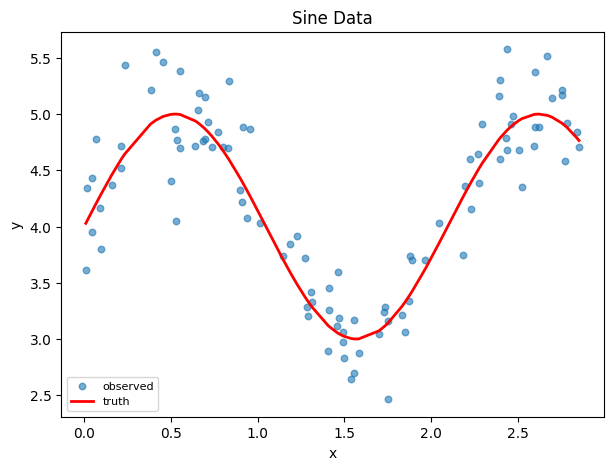

In [127]:
# Visualize the simulated data before fitting models.
fig, axes = plt.subplots(1, 1, figsize=(7, 5))
plot_data(data, axes, "Sine Data")


## Experimentation

### Simple Linear Regression Exploration

In [128]:
# Hold out 20% of the data for an initial simple train/test demonstration.
train_set, test_set = train_test_split(data, test_size=0.20, random_state=RANDOM_SEED)


In [129]:
# Fit a simple linear regression baseline using only the raw x predictor.
lr_model = LinearRegression().fit(train_set[['x']], train_set['y'])


In [130]:
# Print the fitted intercept and slope to inspect the estimated linear trend.
print(lr_model.intercept_)
print(lr_model.coef_[0])


4.2621616163109035
0.01925302023850662


In [131]:
# Predict responses for the held-out test set using the fitted linear model.
preds = lr_model.predict(test_set[['x']])


In [132]:
# Display the raw prediction vector for the held-out observations.
preds


array([4.26622501, 4.30157362, 4.30906743, 4.27703818, 4.29584892,
       4.26234535, 4.26391141, 4.29037021, 4.30900549, 4.26344591,
       4.27537131, 4.29776957, 4.30598979, 4.2954235 , 4.27553605,
       4.28684199, 4.3063452 , 4.28417173, 4.29209034, 4.30585513])

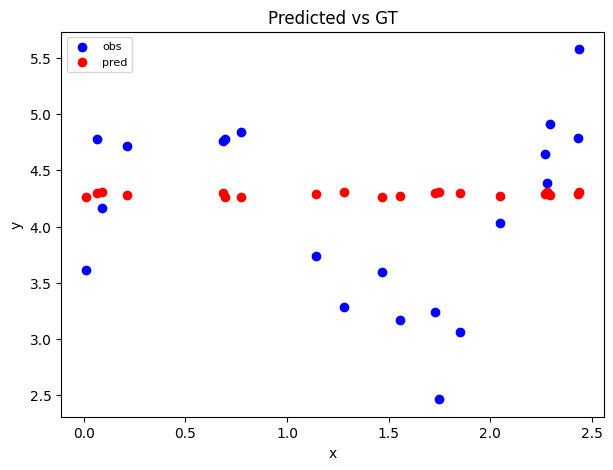

In [133]:
# Compare held-out observations with simple linear-regression predictions.
fig, axes = plt.subplots(1, 1, figsize=(7, 5))

# Sort the test points by x so plotted predictions are easier to read from left to right.
order = np.argsort(test_set['x'].to_numpy())

# Plot the observed test responses and their corresponding model predictions.
axes.scatter(test_set['x'], test_set['y'], color='blue', label='obs')
axes.scatter(test_set['x'].to_numpy()[order], preds, color='red', label='pred')

# Label the diagnostic plot.
axes.set_title('Predicted vs GT')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.legend(fontsize=8)


### Polynomial Feature Exploration

In [134]:
# Recreate the same split for the polynomial-regression exploration.
train_set, test_set = train_test_split(data, test_size=0.20, random_state=RANDOM_SEED)


In [135]:
# Five-fold CV estimates prediction error while keeping validation folds reproducible.
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


In [136]:
# Leave-one-out CV trains on n-1 observations and validates on the single held-out point.
loo = LeaveOneOut()


In [137]:
# Degree 3 polynomial regression fits y = b0 + b1*x + b2*x^2 + b3*x^3.
# The pipeline first expands x into polynomial features, then fits ordinary least squares.
pr_model = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression()
)


In [138]:
# cross_val_score returns negative MSE for this scorer, so multiply by -1 to get MSE.
kfold_mse = -cross_val_score(pr_model, X, y, cv=kfold, scoring='neg_mean_squared_error')

# Display fold-level MSE values to see how variable the validation error is across folds.
kfold_mse


array([0.39779865, 0.20876633, 0.30491519, 0.36455432, 0.42083109])

In [139]:
# Average the fold-level MSE values to summarize k-fold CV performance.
float(np.average(kfold_mse))


0.3393731159617358

In [140]:
# Get out-of-fold predictions: each yhat is produced by a model that did not train on it.
kfold_preds = cross_val_predict(pr_model, X, y, cv=kfold)

# Display the prediction vector for inspection.
kfold_preds


array([4.67931165, 4.60294961, 4.52758802, 4.552191  , 4.72484554,
       4.74010996, 4.68536571, 4.61781694, 4.78314283, 4.64510633,
       4.63418152, 4.76717101, 4.62975641, 4.58822864, 4.72318828,
       4.55069756, 4.70580448, 4.651557  , 4.52925614, 4.55519894,
       4.62110427, 4.47591559, 4.44363796, 4.53846329, 4.52970403,
       4.53516116, 4.55365161, 4.37515788, 4.44533893, 4.33625442,
       4.42877229, 4.29829955, 4.3228292 , 4.21469115, 4.187351  ,
       4.18042896, 4.25332956, 4.20501475, 3.98632007, 3.87914608,
       3.83958952, 3.79642214, 3.81820934, 3.85849438, 3.83929754,
       3.83198782, 3.71521861, 3.71199694, 3.66292149, 3.66333981,
       3.62727765, 3.66729672, 3.6055309 , 3.59440033, 3.64177674,
       3.5907871 , 3.55395609, 3.57624831, 3.5522737 , 3.51259375,
       3.46268053, 3.50697073, 3.47894763, 3.45669766, 3.51285799,
       3.44812126, 3.46116848, 3.46187681, 3.4639059 , 3.53038523,
       3.53313376, 3.82575836, 3.75270017, 3.75289028, 3.81768

In [141]:
# Compute the MSE from the out-of-fold predictions directly.
mse = mean_squared_error(y, kfold_preds)
mse


0.33937311596173586

In [142]:
# Run leave-one-out CV for the same polynomial model.
loo_mse = -cross_val_score(pr_model, X, y, cv=loo, scoring='neg_mean_squared_error')

# Display one squared-error value per held-out observation.
loo_mse


array([1.15629042e+00, 6.45034217e-02, 3.35940147e-02, 5.11672930e-01,
       3.40038069e-02, 2.59503387e-01, 8.20779517e-01, 1.07309850e-01,
       6.12343090e-04, 3.46909704e-02, 5.94080496e-01, 2.84559639e-01,
       7.96920532e-01, 6.70499653e-01, 6.16233917e-02, 5.80130607e-02,
       3.63786018e-01, 2.36595615e-02, 6.35610286e-01, 8.18265763e-03,
       3.08967435e-02, 2.70949474e-01, 4.69428780e-01, 6.85609223e-02,
       8.62701289e-02, 4.59485753e-01, 2.17491810e-01, 6.54859847e-02,
       1.91906233e-01, 1.04969238e-01, 1.22083754e-01, 9.50677747e-01,
       2.21577058e-03, 2.88844999e-03, 4.13840636e-01, 2.66103521e-02,
       4.61725484e-01, 1.21966596e-02, 6.20777297e-02, 7.64818670e-03,
       7.50163848e-04, 1.30903956e-02, 3.08372218e-01, 3.87662140e-01,
       1.48573919e-01, 2.19401636e-01, 6.70280359e-01, 1.96353587e-01,
       5.59884941e-02, 2.97776643e-01, 2.11198283e-03, 2.11262091e-01,
       4.38484654e-01, 3.25024253e-01, 6.49870706e-01, 9.28791650e-01,
      

In [143]:
# Average the LOOCV errors to get the overall LOOCV MSE estimate.
float(np.average(loo_mse))


0.34273573999068346

### Kernel Smoothers Exploration

In [144]:
# Recreate the train/test split for the kernel-smoother exploration.
train_set, test_set = train_test_split(data, test_size=0.20, random_state=RANDOM_SEED)


In [145]:
# Fit a local-constant kernel regression smoother on the training data.
kr = KernelReg(
    exog=train_set['x'],       # Predictor values used to locate nearby observations.
    endog=train_set['y'],      # Response values averaged by the local kernel smoother.
    var_type="c",             # "c" marks x as a continuous predictor.
    reg_type="lc"             # "lc" requests local-constant regression.
)


In [146]:
# Predict at the held-out x values; slope_est is returned by statsmodels but unused here.
preds, slope_est = kr.fit(test_set['x'])


In [147]:
# Sort test observations and predictions so the diagnostic plot is ordered by x.
order = np.argsort(test_set['x'].to_numpy())

x_test_sorted = test_set['x'].to_numpy()[order]
y_test_sorted = test_set['y'].to_numpy()[order]
preds_sorted = preds[order]


In [148]:
# Compute held-out MSE for the exploratory kernel smoother fit.
mean_squared_error(y_test_sorted, preds_sorted)


0.13319196901591046

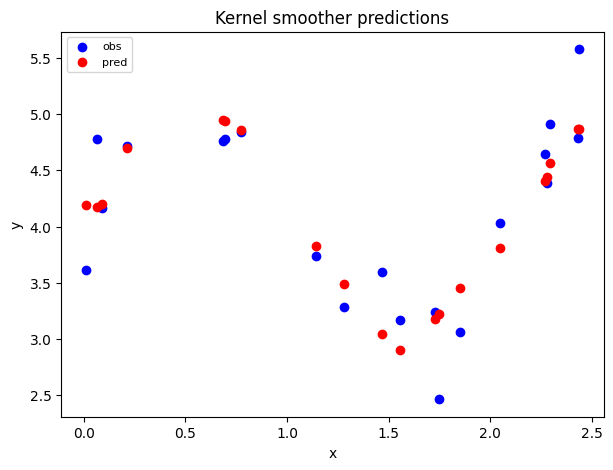

In [149]:
# Plot kernel-smoother predictions against the held-out observations.
plt.figure(figsize=(7, 5))

plt.scatter(test_set['x'], test_set['y'], color='blue', label='obs')
plt.scatter(x_test_sorted, preds_sorted, color='red', label='pred')

plt.title('Kernel smoother predictions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(fontsize=8)
plt.show()


## Building Functions for Testing Each Method

### Polynomial Regression

In [150]:
def fit_poly_reg(X, y, cv_type, deg, k=5, seed=RANDOM_SEED):
    """Return CV MSE for polynomial regression at a chosen polynomial degree."""

    # Build the requested cross-validation splitter.
    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'kfold' or 'loo'")

    # Expand x into powers up to deg, then fit ordinary least squares to those features.
    model = make_pipeline(
        PolynomialFeatures(degree=deg, include_bias=False),
        LinearRegression()
    )

    # Convert sklearn's negative-MSE convention back to positive MSE and average folds.
    mse_vals = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
    return float(np.average(mse_vals))


In [151]:
# Smoke-test the polynomial helper with 5-fold CV and degree 3.
fit_poly_reg(X, y, "kfold", 3)


0.3393731159617358

### Splines

In [152]:
def fit_spline(X, y, cv_type, n_knots, k=5, seed=RANDOM_SEED, deg=3):
    """Return CV MSE for spline regression at a chosen number of knots."""

    # Build the requested cross-validation splitter.
    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'kfold' or 'loo'")

    # Build cubic spline basis functions and fit a linear regression on that basis.
    model = make_pipeline(
        SplineTransformer(n_knots=n_knots, degree=deg, include_bias=False),
        LinearRegression()
    )

    # Estimate prediction error by averaging validation MSE across the CV folds.
    mse_vals = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
    return float(np.average(mse_vals))


In [153]:
# Smoke-test the spline helper with 5-fold CV and 3 knots.
fit_spline(X, y, "kfold", 3)


0.1253390070598247

In [ ]:
def fit_lasso(X, y, cv_type, alpha, k=5, seed=RANDOM_SEED, max_iter = 10000):

    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'kfold' or 'loo'")

    model = make_pipeline(
        StandardScaler(),
        Lasso(alpha=alpha, max_iter=max_iter)
    )

    mse_vals = -cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")

    return float(np.average(mse_vals))

In [ ]:
fit_lasso(X, y, "kfold", 0.1,)

1.0632198610647245

### Kernel Smoothers

In [154]:
def kernel_weights(u, kernel_type):
    """Evaluate kernel weights for standardized distances u."""

    # Most kernels depend on the absolute standardized distance from the target point.
    abs_u = np.abs(u)

    if kernel_type == "epanechnikov":
        # Compact-support quadratic kernel: positive only when |u| <= 1.
        return np.where(abs_u <= 1, 0.75 * (1 - u**2), 0.0)

    elif kernel_type == "gaussian":
        # Smooth infinite-support kernel; the normalizing constant cancels in weighted means.
        return np.exp(-0.5 * u**2)

    elif kernel_type == "tricube":
        # Compact-support kernel often used in local regression smoothers.
        return np.where(abs_u <= 1, (1 - abs_u**3)**3, 0.0)

    elif kernel_type == "uniform":
        # Boxcar kernel: all observations inside the bandwidth get equal weight.
        return np.where(abs_u <= 1, 1.0, 0.0)

    else:
        raise ValueError(
            "kernel_type must be one of: "
            "'epanechnikov', 'gaussian', 'tricube', or 'uniform'"
        )


In [155]:
def nadaraya_watson_predict(x_train, y_train, x_test, bandwidth, kernel_type="epanechnikov"):
    """
    Predict with a Nadaraya-Watson kernel smoother.

    For each test point x0, compute a weighted average of the training responses.
    Training points closer to x0 get larger weights, controlled by the bandwidth.
    """

    # Flatten inputs because this custom smoother operates on one predictor only.
    x_train = np.asarray(x_train).reshape(-1)
    y_train = np.asarray(y_train).reshape(-1)
    x_test = np.asarray(x_test).reshape(-1)

    # Interpret bandwidth as a multiplier of the average x spacing for this data set.
    x_sorted = np.sort(x_train)
    mean_spacing = np.mean(np.diff(x_sorted))
    bandwidth = bandwidth * mean_spacing

    # Allocate one prediction for each requested test location.
    preds = np.empty(len(x_test))

    for j, x0 in enumerate(x_test):
        # Standardize distances so the kernel can convert distance into weights.
        u = (x_train - x0) / bandwidth
        weights = kernel_weights(u, kernel_type)

        if np.sum(weights) == 0:
            # Compact-support kernels can produce no neighbors for very small bandwidths.
            # In that case, fall back to the nearest observed response instead of NaN.
            nearest_idx = np.argmin(np.abs(x_train - x0))
            preds[j] = y_train[nearest_idx]
        else:
            # Weighted average of observed y values gives the smoother prediction at x0.
            preds[j] = np.sum(weights * y_train) / np.sum(weights)

    return preds


In [156]:
def fit_ksmooth(X, y, cv_type, bandwidth, kernel_type="epanechnikov", k=5, seed=RANDOM_SEED):
    """Return CV MSE for the custom Nadaraya-Watson kernel smoother."""

    # Flatten inputs because the custom smoother is written for a single predictor.
    X = np.asarray(X).reshape(-1)
    y = np.asarray(y).reshape(-1)

    # Build the requested cross-validation splitter.
    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'kfold' or 'loo'")

    # Store the validation MSE from each fold before averaging.
    mse_vals = []

    for train_idx, test_idx in cv.split(X):
        # Split each fold into training and validation pieces by index.
        x_train = X[train_idx]
        y_train = y[train_idx]
        x_test = X[test_idx]
        y_test = y[test_idx]

        # Fit/predict the smoother implicitly by predicting from the training data.
        preds = nadaraya_watson_predict(
            x_train=x_train,
            y_train=y_train,
            x_test=x_test,
            bandwidth=bandwidth,
            kernel_type=kernel_type
        )

        # Measure prediction error on the fold's held-out validation points.
        mse_vals.append(mean_squared_error(y_test, preds))

    return float(np.mean(mse_vals))


In [157]:
# Smoke-test the kernel smoother helper with bandwidth multiplier 10.
fit_ksmooth(X, y, 'kfold', 10)


0.12694606116953283

### Loess/Lowess

In [158]:
def fit_loess(X, y, cv_type, span, k=5, seed=RANDOM_SEED, it=0):
    """Return CV MSE for LOWESS/LOESS at a chosen span value."""

    # Flatten inputs because statsmodels.lowess expects one-dimensional x and y arrays.
    X = np.asarray(X).reshape(-1)
    y = np.asarray(y).reshape(-1)

    # Build the requested cross-validation splitter.
    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'kfold' or 'loo'")

    # Store the validation MSE from each fold before averaging.
    mse_vals = []

    for train_idx, test_idx in cv.split(X):
        # Split each fold into training and validation pieces by index.
        x_train = X[train_idx]
        y_train = y[train_idx]
        x_test = X[test_idx]
        y_test = y[test_idx]

        # Predict directly at the held-out x values using only the fold's training data.
        preds = lowess(
            endog=y_train,
            exog=x_train,
            frac=span,
            it=it,
            xvals=x_test
        )

        # Measure prediction error on the fold's held-out validation points.
        mse_vals.append(mean_squared_error(y_test, preds))

    return float(np.mean(mse_vals))


In [159]:
# Smoke-test the LOESS helper with span 0.1.
fit_loess(X, y, "kfold", .1)


0.13089155012803638

## Function Test Methods

In [ ]:
def _get_xy_from_data(data):
    """Accept either the notebook dataframe or an (X, y) pair and return clean arrays."""

    if isinstance(data, pd.DataFrame):
        # The dataframe path is the normal path for this notebook's simulated data.
        if not {"x", "y"}.issubset(data.columns):
            raise ValueError("data must contain 'x' and 'y' columns")
        X_vals = data[["x"]].to_numpy()
        y_vals = data["y"].to_numpy()
    elif isinstance(data, (tuple, list)) and len(data) >= 2:
        # Allow test_methods((X, y)) in case the caller already has arrays.
        X_vals, y_vals = data[0], data[1]
    else:
        raise ValueError("data must be a DataFrame with 'x' and 'y' columns or a tuple/list like (X, y)")

    # Keep X two-dimensional for sklearn methods and y one-dimensional for metrics.
    X_vals = np.asarray(X_vals)
    if X_vals.ndim == 1:
        X_vals = X_vals.reshape(-1, 1)
    y_vals = np.asarray(y_vals).reshape(-1)

    return X_vals, y_vals


In [ ]:
def _get_tuning_number(tuning_value):
    """Extract the numeric part from strings like 'degree=3' or 'span=0.2'."""

    return float(str(tuning_value).split("=")[1])


In [ ]:
def _predict_best_fit(X_train, y_train, method, tuning_value):
    """Fit the selected method on all data and predict on a dense x grid for plotting."""

    # Flatten copies for custom smoothers and build a 2D grid for sklearn estimators.
    x_train = np.asarray(X_train).reshape(-1)
    y_train = np.asarray(y_train).reshape(-1)
    x_grid = np.linspace(x_train.min(), x_train.max(), 300)
    X_grid = x_grid.reshape(-1, 1)

    # Convert the stored tuning label into the numeric value needed by the model.
    tuning_num = _get_tuning_number(tuning_value)

    if method == "Polynomial Regression":
        # Refit the best polynomial degree on the full data set before plotting.
        model = make_pipeline(
            PolynomialFeatures(degree=int(tuning_num), include_bias=False),
            LinearRegression()
        )
        model.fit(X_train, y_train)
        y_grid = model.predict(X_grid)
    elif method == "Spline Regression":
        # Refit the best spline basis size on the full data set before plotting.
        model = make_pipeline(
            SplineTransformer(n_knots=int(tuning_num), degree=3, include_bias=False),
            LinearRegression()
        )
        model.fit(X_train, y_train)
        y_grid = model.predict(X_grid)
    elif method == "Kernel Smoother":
        # Kernel smoothing predicts directly from all training points at the grid locations.
        y_grid = nadaraya_watson_predict(
            x_train=x_train,
            y_train=y_train,
            x_test=x_grid,
            bandwidth=tuning_num
        )
    elif method == "LOESS":
        # LOWESS can return predictions at requested x values through the xvals argument.
        y_grid = lowess(
            endog=y_train,
            exog=x_train,
            frac=tuning_num,
            it=0,
            xvals=x_grid
        )
    else:
        raise ValueError(f"Unknown method: {method}")

    return x_grid, y_grid


In [ ]:
def _plot_best_fit(data, X_train, y_train, best_row):
    """Plot observed data, optional truth, and the fitted curve selected by CV."""

    # Flatten x for plotting while preserving the 2D matrix for sklearn refits.
    x_train = np.asarray(X_train).reshape(-1)

    # Generate fitted values from the CV-selected method and tuning value.
    x_grid, y_grid = _predict_best_fit(
        X_train=X_train,
        y_train=y_train,
        method=best_row["method"],
        tuning_value=best_row["tuning_value"]
    )

    # Start with the observed noisy data.
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    ax.scatter(x_train, y_train, s=22, alpha=0.60, label="observed")

    # Overlay the known simulated truth when this notebook's dataframe is provided.
    if isinstance(data, pd.DataFrame) and "truth" in data.columns:
        order = np.argsort(data["x"].to_numpy())
        ax.plot(
            data["x"].to_numpy()[order],
            data["truth"].to_numpy()[order],
            color="red",
            linewidth=2,
            alpha=0.70,
            label="truth"
        )

    # Draw the fitted curve from the winning method/tuning pair.
    ax.plot(
        x_grid,
        y_grid,
        color="black",
        linewidth=2.5,
        label=f"best fit: {best_row['method']} ({best_row['tuning_value']})"
    )

    # Label the plot so it can be interpreted without surrounding notebook text.
    ax.set_title("Best fitted curve on full data")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)
    plt.show()


In [ ]:
def test_methods(data, cv_type="kfold", k=5, seed=RANDOM_SEED, plot_fit=False):
    """Test all candidate methods across tuning grids and return a sorted MSE table."""

    # Normalize the input into arrays usable by every helper function.
    X_test, y_test = _get_xy_from_data(data)

    # Candidate tuning grids. They are intentionally moderate so the whole search is quick.
    tuning_grids = {
        "Polynomial Regression": range(1, 11),
        "Spline Regression": range(3, 11),
        "Kernel Smoother": [2, 4, 6, 8, 10, 12, 15, 20],
        "LOESS": [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.75],
    }

    # Accumulate one row per method/tuning combination.
    results = []

    # Polynomial degree controls curve flexibility; higher degree can fit more wiggle.
    for deg in tuning_grids["Polynomial Regression"]:
        results.append({
            "method": "Polynomial Regression",
            "tuning_value": f"degree={deg}",
            "mse": fit_poly_reg(X_test, y_test, cv_type, deg, k=k, seed=seed)
        })

    # Number of spline knots controls how many local basis functions are available.
    for n_knots in tuning_grids["Spline Regression"]:
        results.append({
            "method": "Spline Regression",
            "tuning_value": f"n_knots={n_knots}",
            "mse": fit_spline(X_test, y_test, cv_type, n_knots, k=k, seed=seed)
        })

    # Bandwidth controls kernel-smoother locality; smaller values make rougher fits.
    for bandwidth in tuning_grids["Kernel Smoother"]:
        results.append({
            "method": "Kernel Smoother",
            "tuning_value": f"bandwidth={bandwidth}",
            "mse": fit_ksmooth(X_test, y_test, cv_type, bandwidth, k=k, seed=seed)
        })

    # Span is the fraction of data used locally by LOESS; smaller values fit more locally.
    for span in tuning_grids["LOESS"]:
        results.append({
            "method": "LOESS",
            "tuning_value": f"span={span}",
            "mse": fit_loess(X_test, y_test, cv_type, span, k=k, seed=seed)
        })

    # Sort so the best-performing combination appears first.
    results_df = pd.DataFrame(results).sort_values("mse").reset_index(drop=True)
    best_row = results_df.iloc[0]

    # Print the winning combination while still returning the complete search table.
    print(
        f"Best combination: method={best_row['method']}, "
        f"tuning_value={best_row['tuning_value']}, "
        f"mse={best_row['mse']:.6f}"
    )

    # Optionally visualize the best method refit on the full data set.
    if plot_fit:
        _plot_best_fit(data, X_test, y_test, best_row)

    return results_df


Best combination: method=Spline Regression, tuning_value=n_knots=6, mse=0.119761


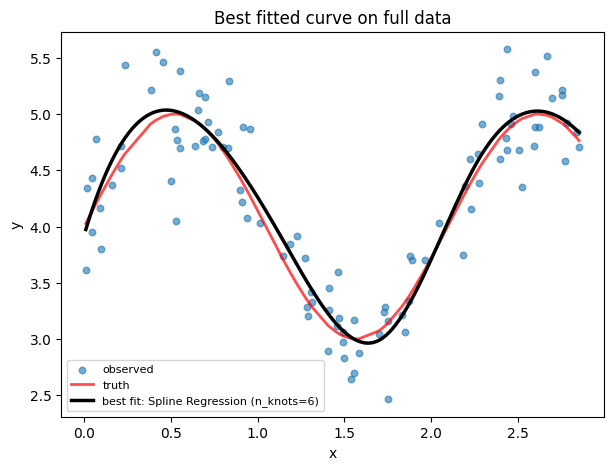

,method,tuning_value,mse
0,Spline Regression,n_knots=6,0.119761
1,Polynomial Regression,degree=8,0.120435
2,Polynomial Regression,degree=9,0.121107
3,Polynomial Regression,degree=7,0.121128
4,Spline Regression,n_knots=7,0.122624
5,LOESS,span=0.2,0.123018
6,Spline Regression,n_knots=8,0.123444
7,LOESS,span=0.25,0.123713
8,LOESS,span=0.15,0.123760
9,LOESS,span=0.3,0.124364


In [161]:
# Run the full model/tuning comparison, print the winner, plot the best fit,
# and display the complete sorted MSE table.
test_results = test_methods(data, plot_fit=True)
test_results
